In [37]:
import os
import random
import numpy as np
import seaborn as sns
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [38]:
train_dir = '/kaggle/input/dataset2/Dataset2/Train'
val_dir = '/kaggle/input/dataset2/Dataset2/Val'
test_dir = '/kaggle/input/dataset2/Dataset2/Test'

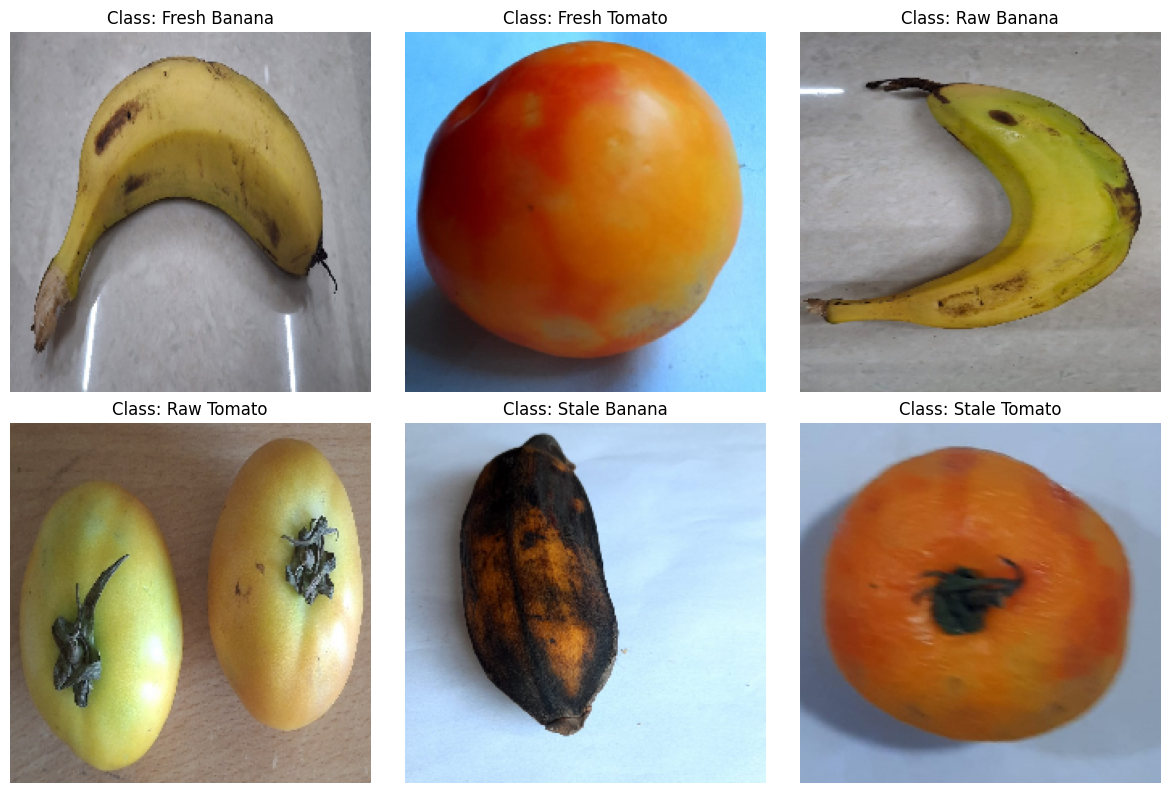

In [39]:
class_names = ['Fresh Banana','Fresh Tomato','Raw Banana','Raw Tomato','Stale Banana','Stale Tomato']

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(class_names):
    class_folder = os.path.join(train_dir, class_name)
    images = os.listdir(class_folder)
    img_path = os.path.join(class_folder, random.choice(images))  
    img = load_img(img_path, target_size=(224, 224))
    
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"Class: {class_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

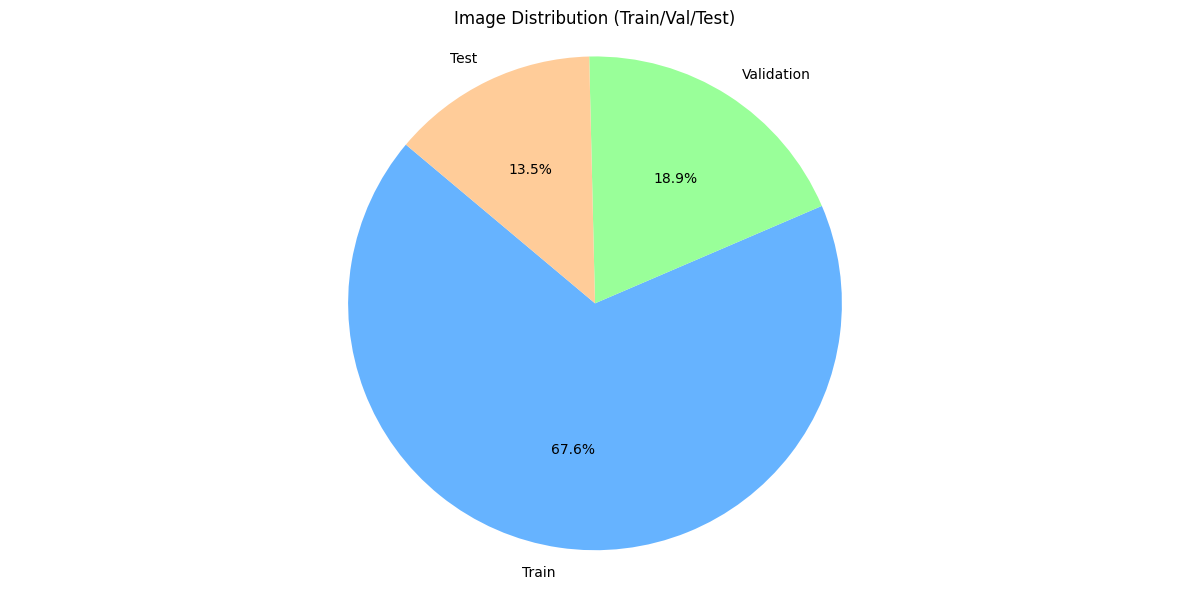

In [40]:
Counts = {
    'Train': sum([25, 25, 25]),
    'Validation': sum([7, 7, 7]),
    'Test': sum([5, 5, 5])
}

plt.figure(figsize=(12, 6))
plt.pie(Counts.values(), labels=Counts.keys(), autopct='%1.1f%%', startangle=140, colors=['#66b3ff', '#99ff99', '#ffcc99'])
plt.title('Image Distribution (Train/Val/Test)')
plt.axis('equal')
plt.tight_layout()
plt.show()


In [41]:
train_dir = '/kaggle/input/fruittype/FruitType/Train'
val_dir = '/kaggle/input/fruittype/FruitType/Val'
test_dir = '/kaggle/input/fruittype/FruitType/Test'

In [42]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=1,  # Important for predictions
    class_mode='categorical',
    shuffle=False
)

print("Class Indices:", train_generator.class_indices)

Found 150 images belonging to 2 classes.
Found 42 images belonging to 2 classes.
Found 30 images belonging to 2 classes.
Class Indices: {'Banana': 0, 'Tomato': 1}


In [43]:
def visualize_feature_maps(model, img_path, num_layers=4, filters_per_layer=8):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    plt.figure(figsize=(4, 4))
    plt.imshow(img_array[0])
    plt.axis('off')
    plt.title("Original Image")
    plt.show()

    conv_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]

    for conv_layer in conv_layers[:num_layers]:  # Limit number of layers shown
        feature_map_model = Model(inputs=model.input, outputs=conv_layer.output)
        feature_maps = feature_map_model.predict(img_array)

        num_filters = feature_maps.shape[-1]
        step = max(1, num_filters // filters_per_layer)
        selected_filters = list(range(0, num_filters, step))[:filters_per_layer]

        fig, axes = plt.subplots(1, filters_per_layer, figsize=(20, 4))
        fig.suptitle(f"Feature Maps from {conv_layer.name}")

        for i, idx in enumerate(selected_filters):
            ax = axes[i]
            ax.imshow(feature_maps[0, :, :, idx], cmap='viridis')
            ax.axis('off')
            ax.set_title(f"Filter {idx}")

        plt.tight_layout()
        plt.show()


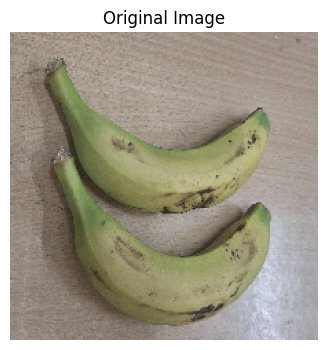

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


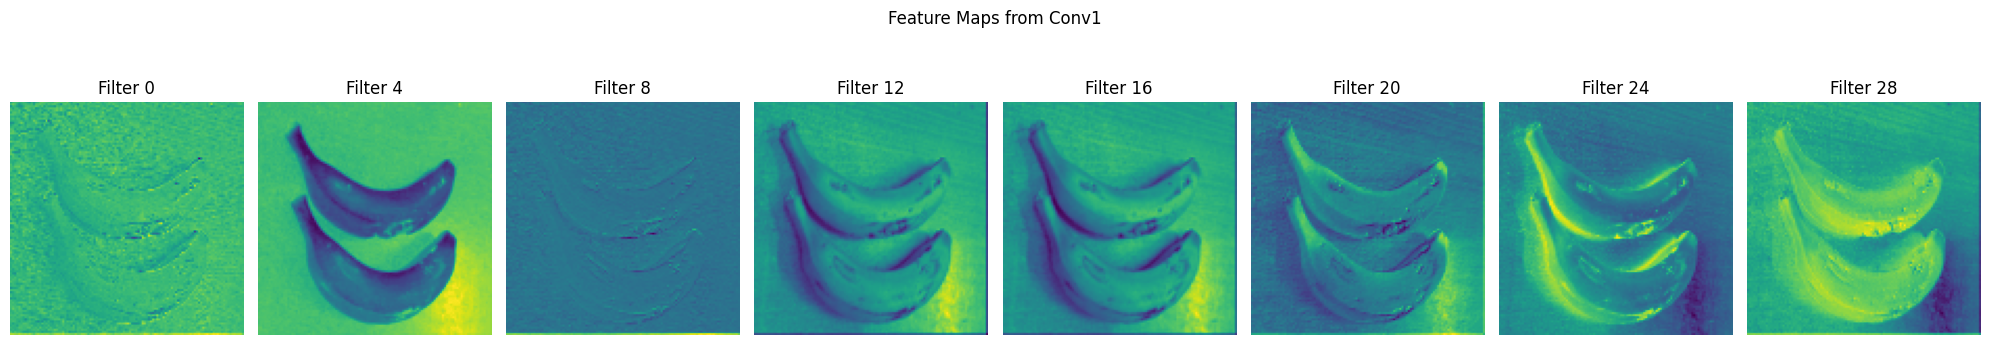

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


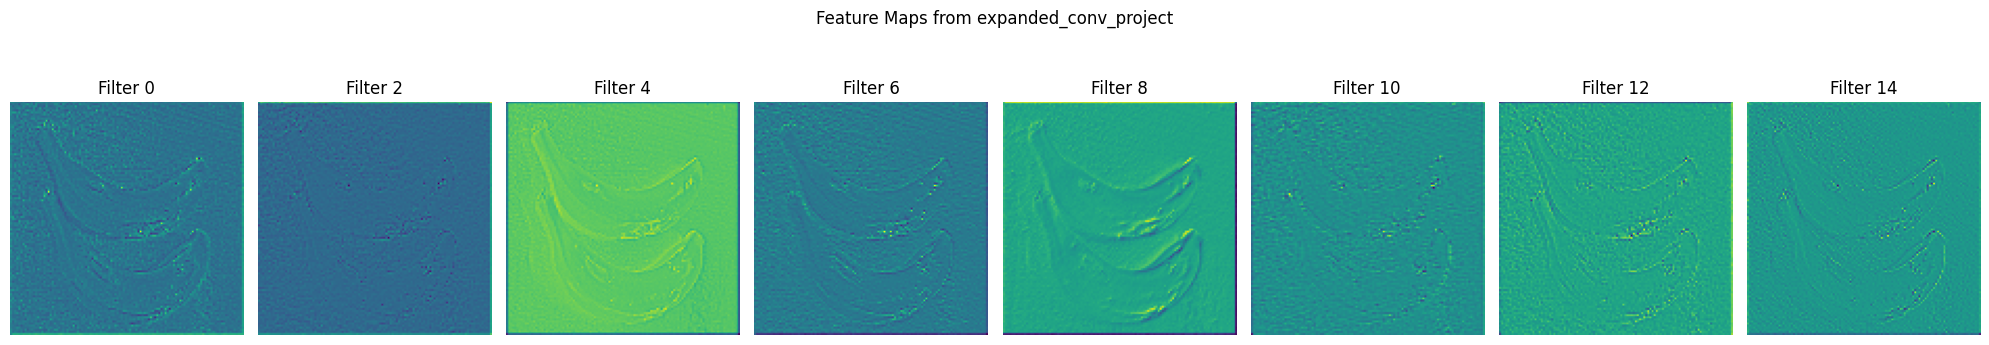

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step


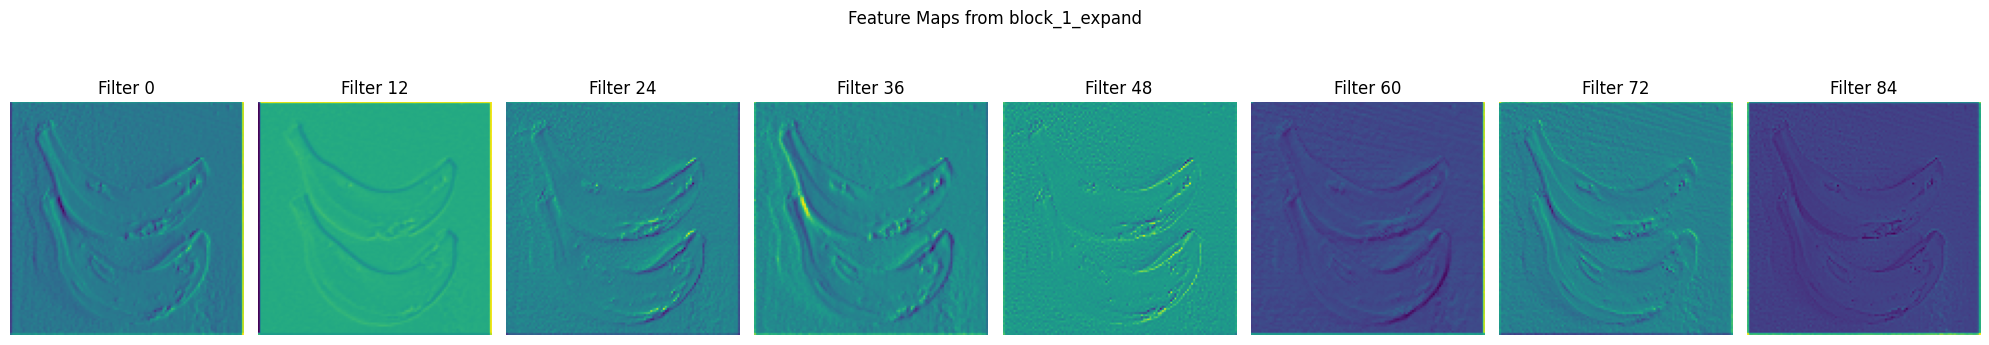

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step


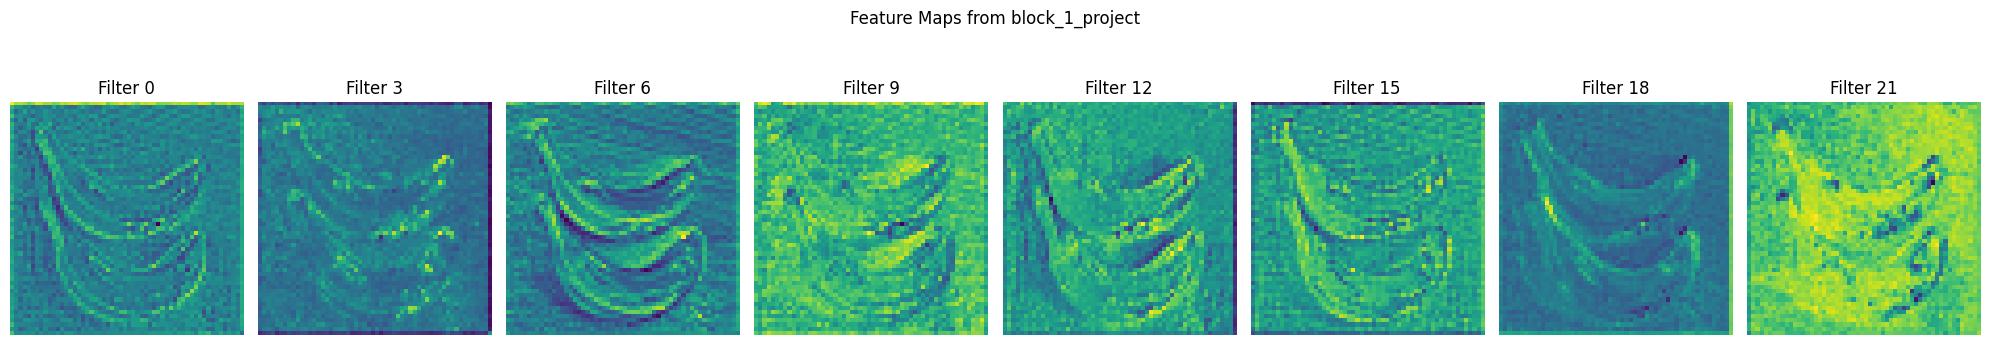

In [44]:
fruit_base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
visualize_feature_maps(fruit_base_model, '/kaggle/input/fruittype/FruitType/Train/Banana/20250213_224901.jpg')

In [45]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False 

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
output = Dense(2, activation='softmax')(x)

fruit_model = Model(inputs=base_model.input, outputs=output)

fruit_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# fruit_model.summary()

In [46]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = fruit_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stopping]
)

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 833ms/step - accuracy: 0.6352 - loss: 0.6051 - val_accuracy: 0.9286 - val_loss: 0.3015
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.8930 - loss: 0.3207 - val_accuracy: 0.9762 - val_loss: 0.1676
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.9466 - loss: 0.1962 - val_accuracy: 1.0000 - val_loss: 0.1015
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.9964 - loss: 0.1097 - val_accuracy: 1.0000 - val_loss: 0.0646
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.9815 - loss: 0.0803 - val_accuracy: 1.0000 - val_loss: 0.0461


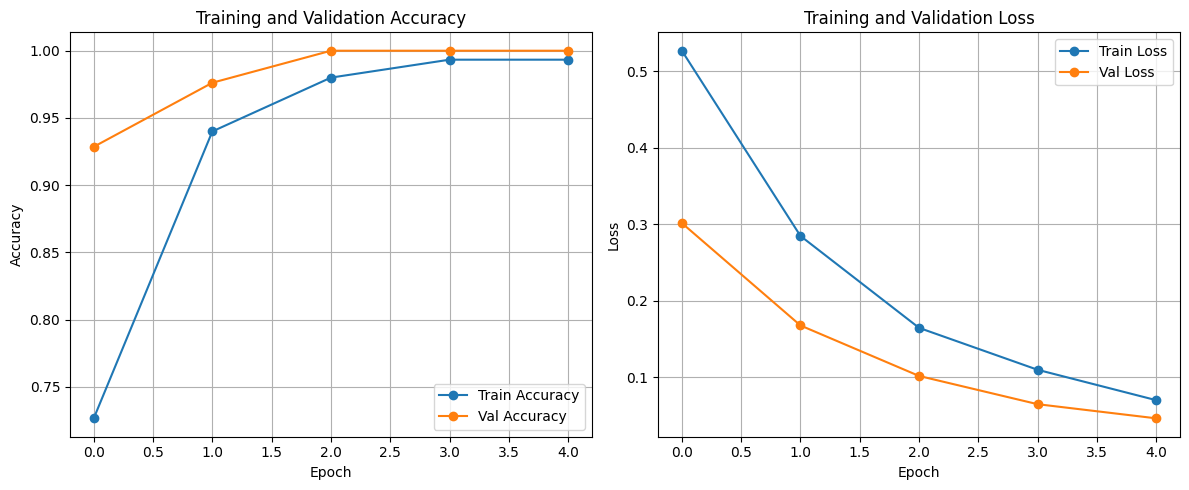

In [47]:
# Accuracy Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


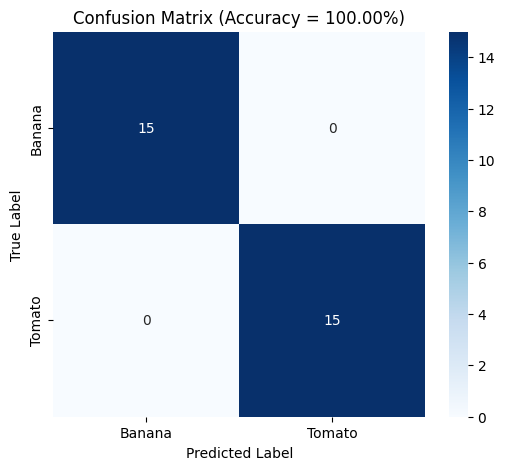

Test Accuracy: 100.00%


In [48]:
test_generator.reset()
preds = fruit_model.predict(test_generator, verbose=1)

y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=list(test_generator.class_indices.keys()),
            yticklabels=list(test_generator.class_indices.keys()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Accuracy = {acc*100:.2f}%)')
plt.show()

print(f"Test Accuracy: {acc*100:.2f}%")

In [49]:
class_labels = list(test_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_labels)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00        15
      Tomato       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



base_model.save('base_model.h5')

In [50]:
train_dir = '/kaggle/input/bananadataset/BananaDataset/Train'
val_dir = '/kaggle/input/bananadataset/BananaDataset/Val'
test_dir = '/kaggle/input/bananadataset/BananaDataset/Test'

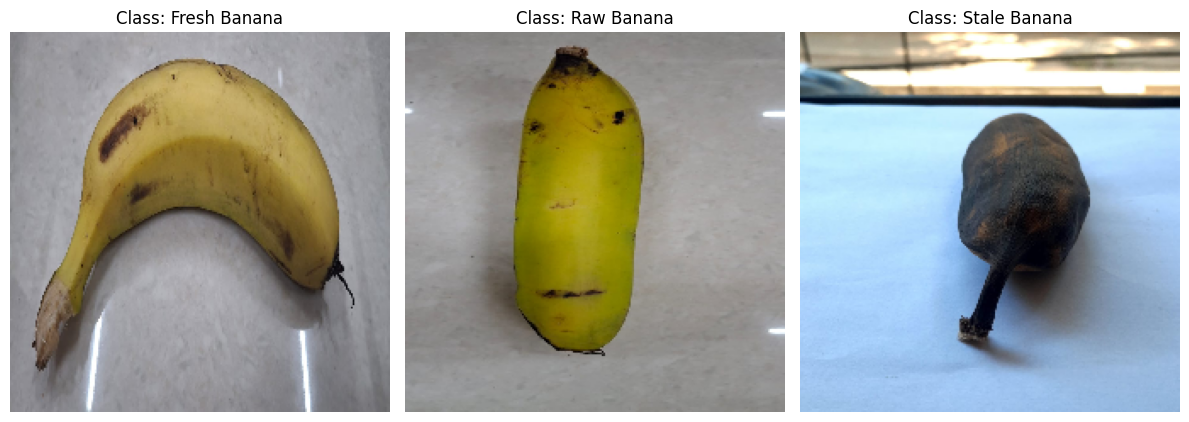

In [51]:
class_names = ['Fresh Banana','Raw Banana','Stale Banana']

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(class_names):
    class_folder = os.path.join(train_dir, class_name)
    images = os.listdir(class_folder)
    img_path = os.path.join(class_folder, random.choice(images))  
    img = load_img(img_path, target_size=(224, 224))
    
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(f"Class: {class_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

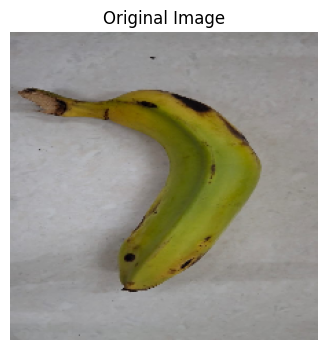

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


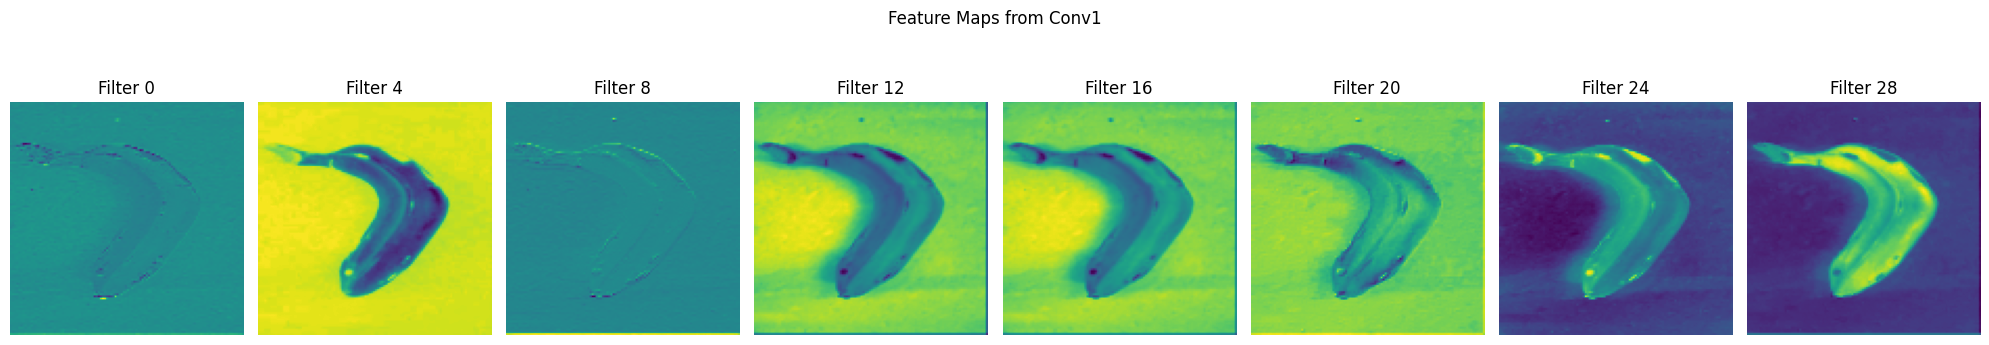

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


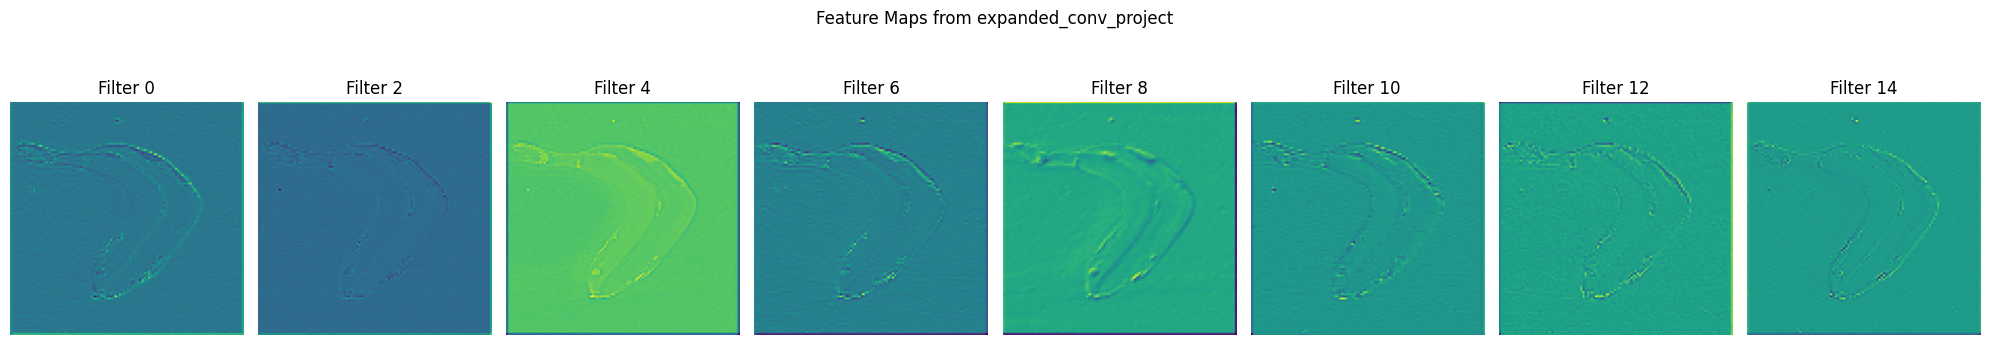

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step


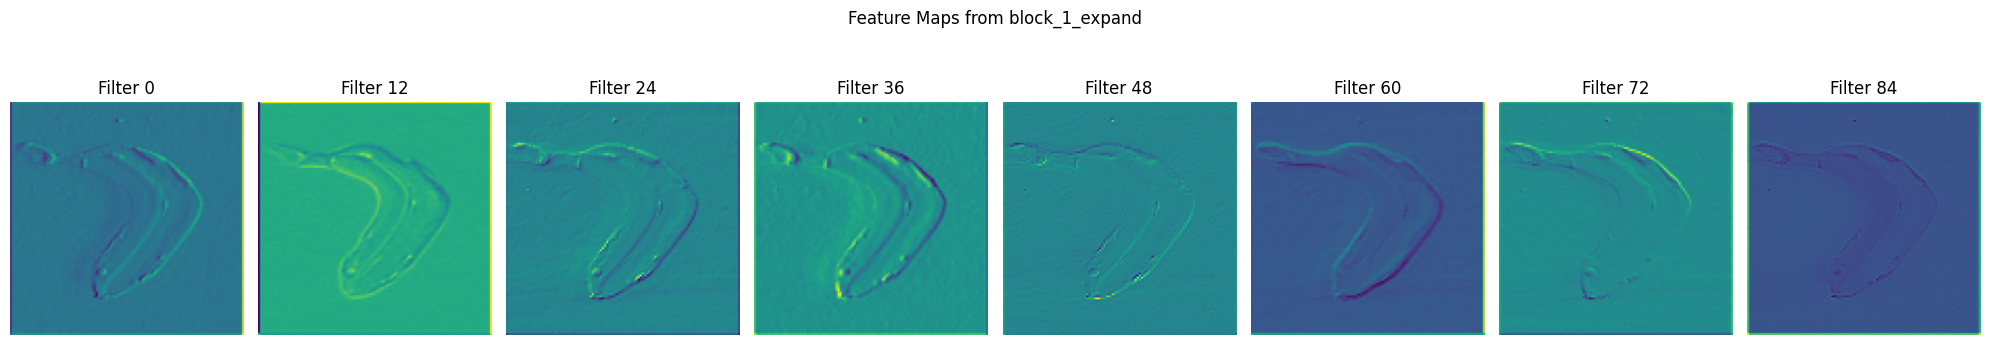

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step


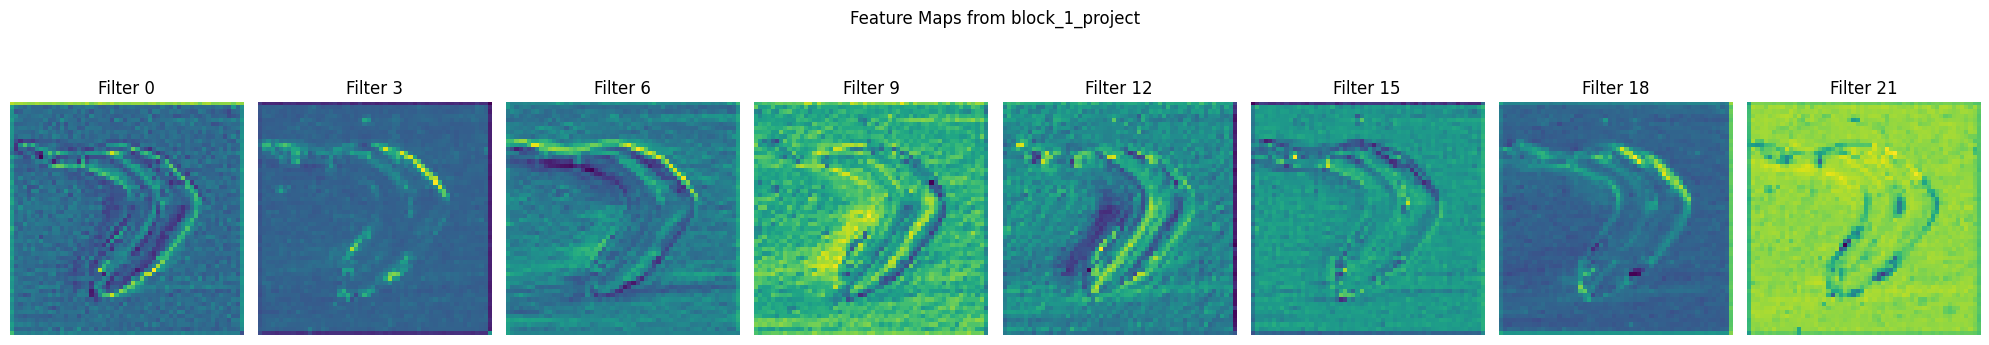

In [52]:
banana_base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
visualize_feature_maps(banana_base_model, '/kaggle/input/bananadataset/BananaDataset/Train/Raw Banana/WhatsApp Image 2025-04-25 at 8.59.10 PM (1).jpeg')


In [53]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

print("Class Indices:", train_generator.class_indices)

Found 75 images belonging to 3 classes.
Found 21 images belonging to 3 classes.
Found 15 images belonging to 3 classes.
Class Indices: {'Fresh Banana': 0, 'Raw Banana': 1, 'Stale Banana': 2}


In [54]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # Freeze base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(3, activation='softmax')(x)  

banana_freshness_model = Model(inputs=base_model.input, outputs=output)

banana_freshness_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [55]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = banana_freshness_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.3065 - loss: 1.2717 - val_accuracy: 0.3333 - val_loss: 1.0306
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.6027 - loss: 0.9467 - val_accuracy: 0.6667 - val_loss: 0.7995
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.7680 - loss: 0.7282 - val_accuracy: 0.7619 - val_loss: 0.6458
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.8701 - loss: 0.5790 - val_accuracy: 0.9048 - val_loss: 0.5277
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.9307 - loss: 0.4622 - val_accuracy: 0.9048 - val_loss: 0.4325
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.9195 - loss: 0.3887 - val_accuracy: 0.9524 - val_loss: 0.3578
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.9488 - loss: 0.3217 - val_accuracy: 0.9524 - val_loss: 0.3058
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.9385 - loss: 0.2526 - val_accuracy: 1.0000 - val_loss: 0.2694
Epoch 9/20
5

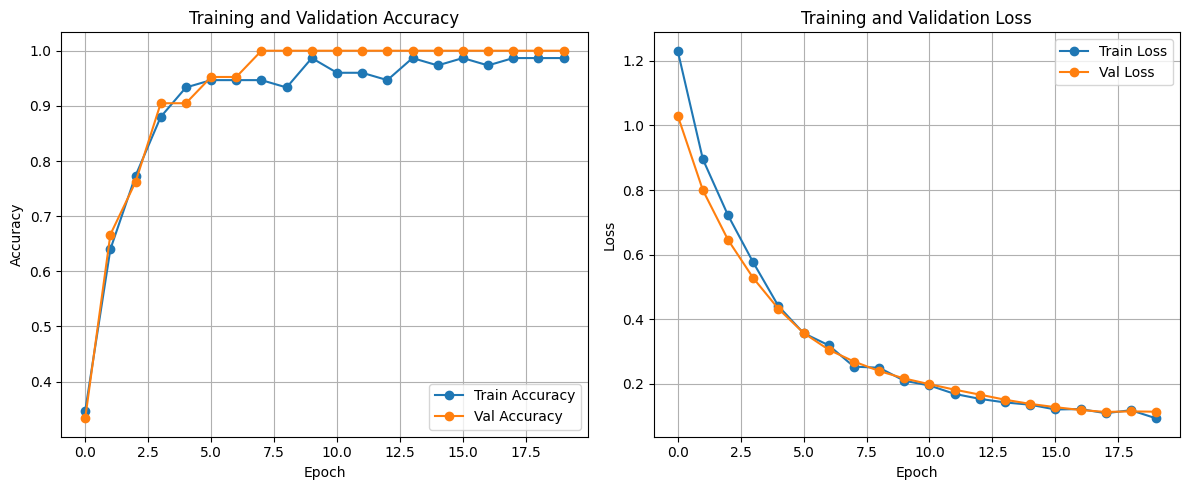

In [56]:
# Accuracy Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step 


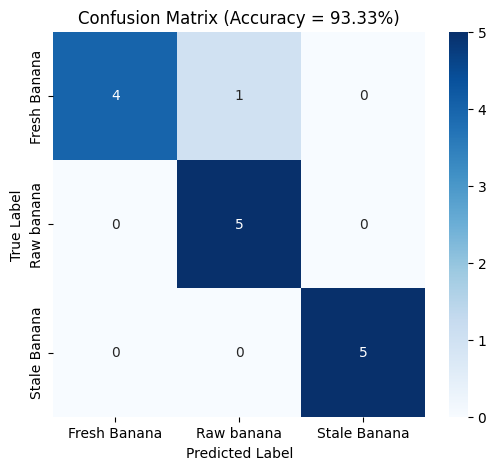

Test Accuracy: 93.33%


In [57]:
test_generator.reset()
preds = banana_freshness_model.predict(test_generator, verbose=1)

y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(test_generator.class_indices.keys()),
            yticklabels=list(test_generator.class_indices.keys()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Accuracy = {acc*100:.2f}%)')
plt.show()

print(f"Test Accuracy: {acc*100:.2f}%")

In [58]:
class_labels = list(test_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_labels)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

Fresh Banana       1.00      0.80      0.89         5
  Raw banana       0.83      1.00      0.91         5
Stale Banana       1.00      1.00      1.00         5

    accuracy                           0.93        15
   macro avg       0.94      0.93      0.93        15
weighted avg       0.94      0.93      0.93        15



banana_freshness_model.save('banana_model.h5')

In [59]:
train_dir = '/kaggle/input/tomatodataset/TomatoDataset/Train'
val_dir = '/kaggle/input/tomatodataset/TomatoDataset/Val'
test_dir = '/kaggle/input/tomatodataset/TomatoDataset/Test'

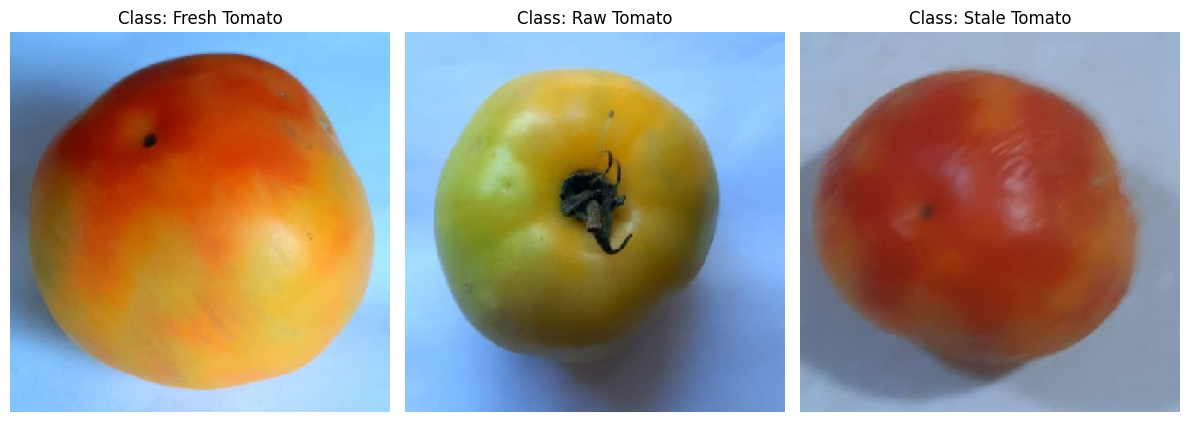

In [60]:
class_names = ['Fresh Tomato','Raw Tomato','Stale Tomato']

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(class_names):
    class_folder = os.path.join(train_dir, class_name)
    images = os.listdir(class_folder)
    img_path = os.path.join(class_folder, random.choice(images))  
    img = load_img(img_path, target_size=(224, 224))
    
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(f"Class: {class_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

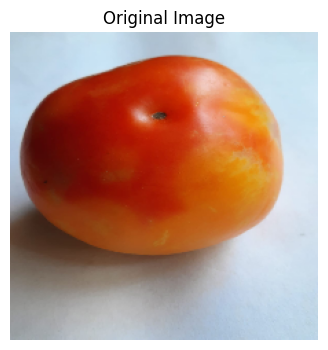

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


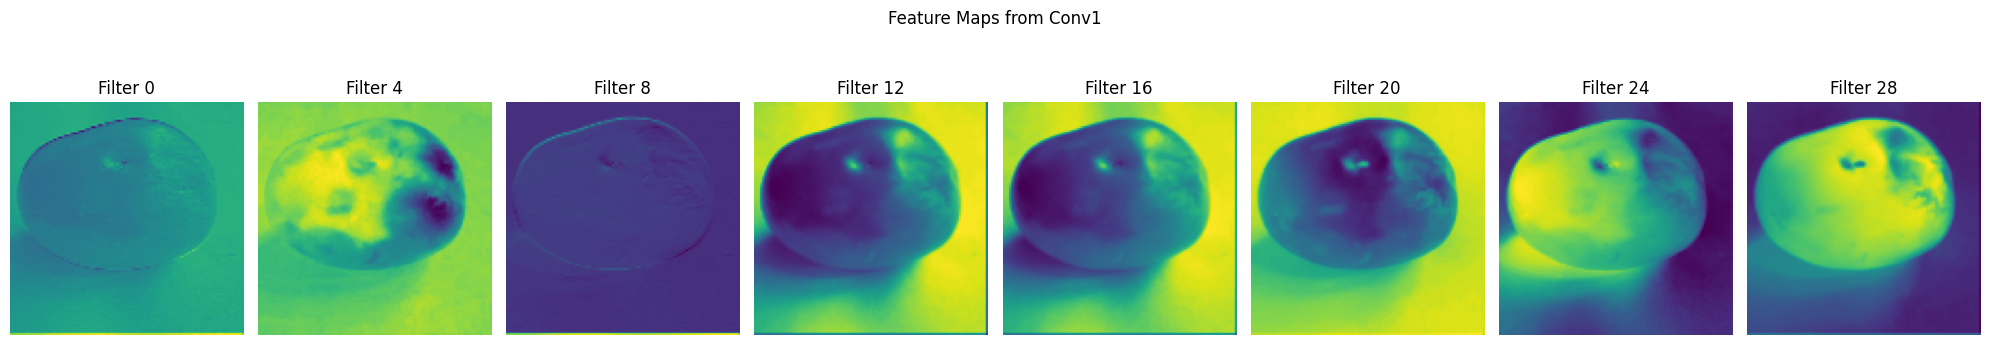

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


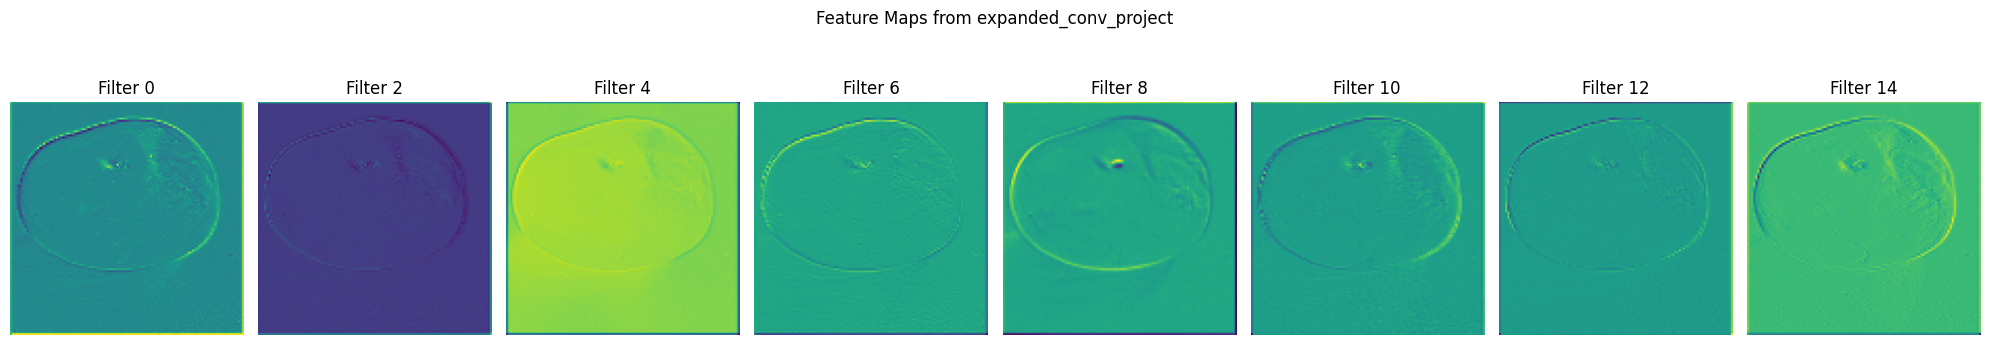

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step


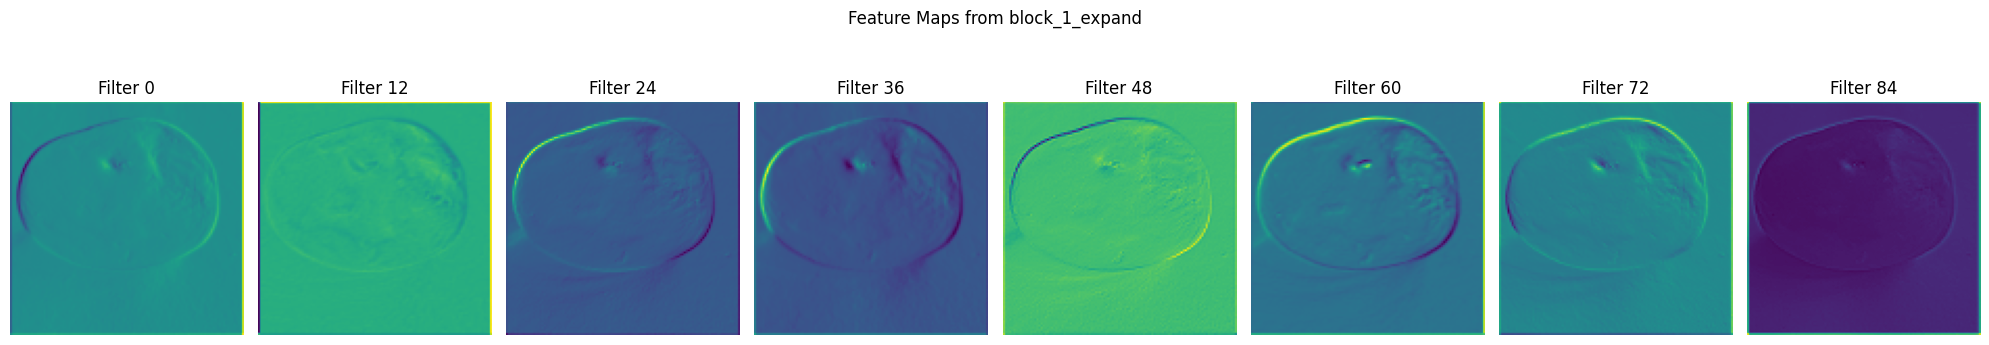

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step


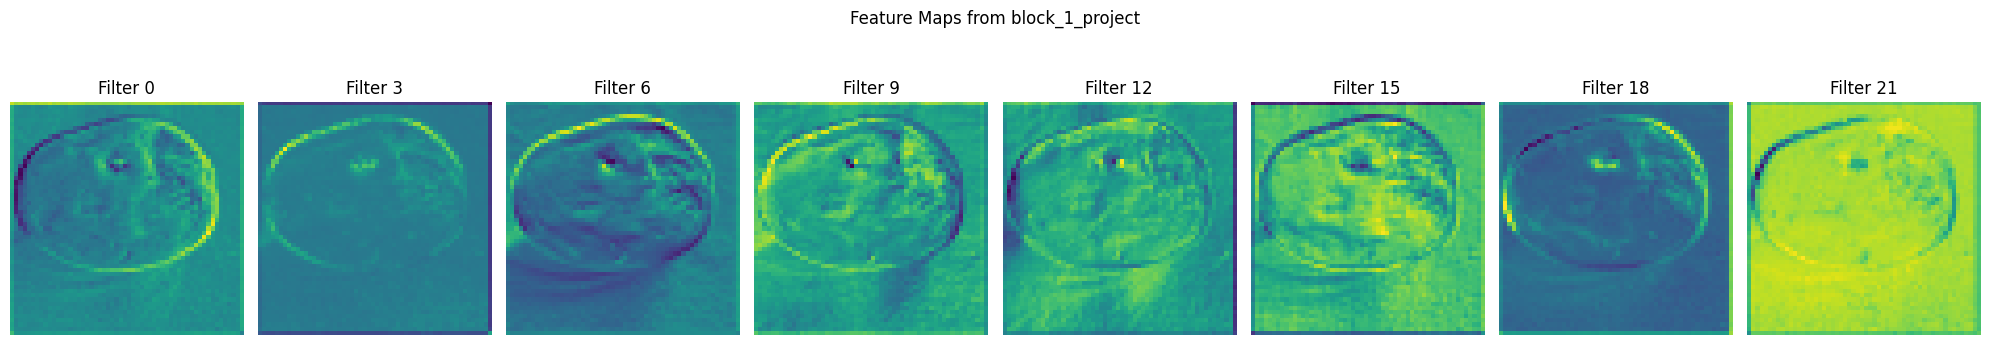

In [61]:
tomato_base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
visualize_feature_maps(tomato_base_model, '/kaggle/input/tomatodataset/TomatoDataset/Train/Fresh Tomato/IMG-20250213-WA0006.jpg')


In [62]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

print("Class Indices:", train_generator.class_indices)

Found 75 images belonging to 3 classes.
Found 21 images belonging to 3 classes.
Found 15 images belonging to 3 classes.
Class Indices: {'Fresh Tomato': 0, 'Raw Tomato': 1, 'Stale Tomato': 2}


In [63]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(3, activation='softmax')(x)  

tomato_freshness_model = Model(inputs=base_model.input, outputs=output)

tomato_freshness_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [64]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = tomato_freshness_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5842 - loss: 0.9981 - val_accuracy: 0.5714 - val_loss: 0.8499
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.5988 - loss: 0.8924 - val_accuracy: 0.8571 - val_loss: 0.6608
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7710 - loss: 0.6975 - val_accuracy: 0.8571 - val_loss: 0.5299
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8860 - loss: 0.5263 - val_accuracy: 0.9048 - val_loss: 0.4309
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.8847 - loss: 0.4294 - val_accuracy: 0.9048 - val_loss: 0.3557
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9385 - loss: 0.3742 - val_accuracy: 0.9524 - val_loss: 0.3001
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9466 - loss: 0.3149 - val_accuracy: 0.9524 - val_loss: 0.2612
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9654 - loss: 0.2831 - val_accuracy: 0.9524 - val_loss: 0.2284
Epoch 9/20
5

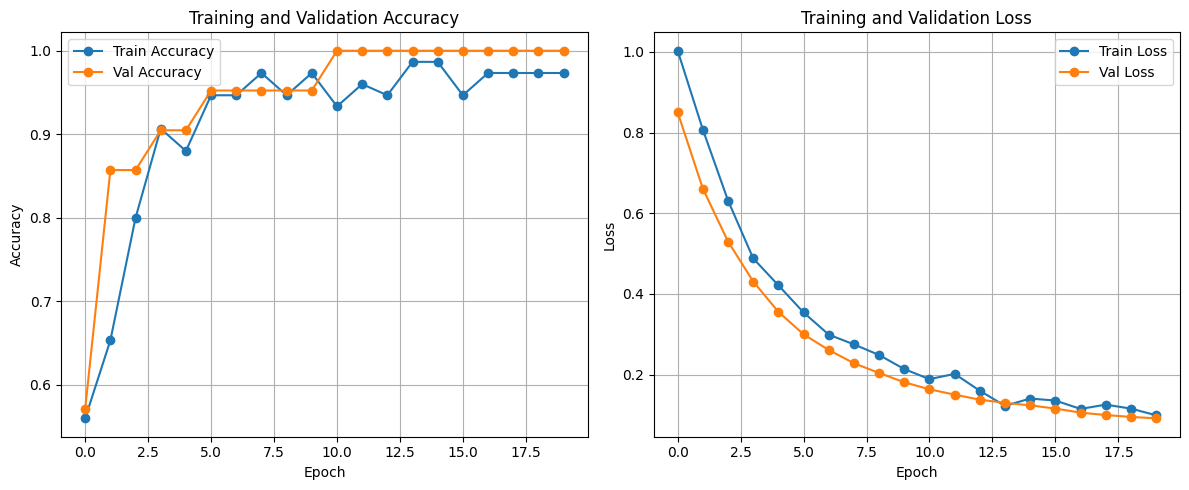

In [65]:
# Accuracy Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


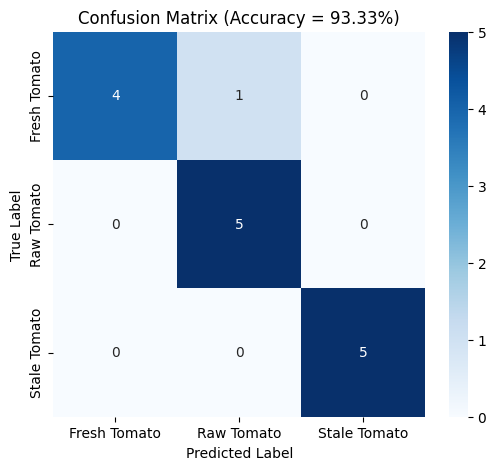

Test Accuracy: 93.33%


In [66]:
test_generator.reset()
preds = tomato_freshness_model.predict(test_generator, verbose=1)

y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(test_generator.class_indices.keys()),
            yticklabels=list(test_generator.class_indices.keys()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Accuracy = {acc*100:.2f}%)')
plt.show()

print(f"Test Accuracy: {acc*100:.2f}%")


In [67]:
class_labels = list(test_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_labels)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

Fresh Tomato       1.00      0.80      0.89         5
  Raw Tomato       0.83      1.00      0.91         5
Stale Tomato       1.00      1.00      1.00         5

    accuracy                           0.93        15
   macro avg       0.94      0.93      0.93        15
weighted avg       0.94      0.93      0.93        15



tomato_freshness_model.save('tomato_model.h5')

In [68]:
fruit_classes = ['Banana', 'Tomato']
banana_freshness_classes = ['Fresh', 'Raw', 'Stale']
tomato_freshness_classes = ['Fresh', 'Raw', 'Stale']

In [69]:
def predict_single_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    fruit_pred = fruit_model.predict(img_array, verbose=0)
    fruit_idx = np.argmax(fruit_pred)
    fruit_label = fruit_classes[fruit_idx]

    if fruit_label == 'Banana':
        freshness_pred = banana_freshness_model.predict(img_array, verbose=0)
        freshness_idx = np.argmax(freshness_pred)
        freshness_label = banana_freshness_classes[freshness_idx]
    elif fruit_label == 'Tomato':
        freshness_pred = tomato_freshness_model.predict(img_array, verbose=0)
        freshness_idx = np.argmax(freshness_pred)
        freshness_label = tomato_freshness_classes[freshness_idx]
    else:
        freshness_label = 'Unknown'

    final_label = f"{freshness_label} {fruit_label}"
    return final_label

In [70]:
def predict_folder(root_folder):
    true_labels = []
    pred_labels = []

    classes = sorted(os.listdir(root_folder))

    for class_name in classes:
        class_folder = os.path.join(root_folder, class_name)
        if not os.path.isdir(class_folder):
            continue

        image_files = [os.path.join(class_folder, fname) for fname in os.listdir(class_folder)
                       if fname.lower().endswith(('.png', '.jpg', '.jpeg'))]

        for img_path in image_files:
            prediction = predict_single_image(img_path)
            
            true_labels.append(class_name.lower().strip())
            pred_labels.append(prediction.lower().strip())

    return true_labels, pred_labels

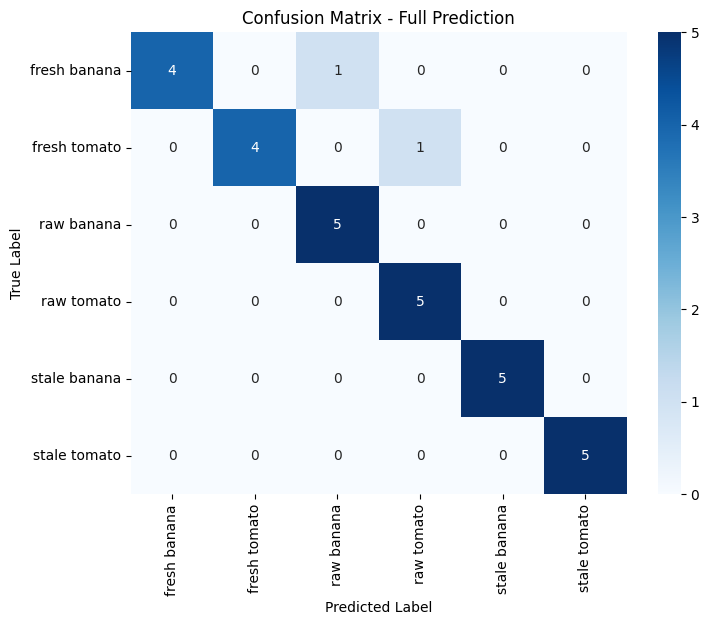

In [71]:
test_folder = '/kaggle/input/dataset2/Dataset2/Test'

y_true, y_pred = predict_folder(test_folder)

labels_sorted = sorted(list(set(y_true + y_pred)))  
cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_sorted,
            yticklabels=labels_sorted)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Full Prediction')
plt.show()

In [72]:
print(classification_report(y_true, y_pred, target_names=labels_sorted))

              precision    recall  f1-score   support

fresh banana       1.00      0.80      0.89         5
fresh tomato       1.00      0.80      0.89         5
  raw banana       0.83      1.00      0.91         5
  raw tomato       0.83      1.00      0.91         5
stale banana       1.00      1.00      1.00         5
stale tomato       1.00      1.00      1.00         5

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [73]:
def predict_and_show_image(img_path, model, class_names):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    # Make prediction
    preds = model.predict(img_array)
    predicted_index = np.argmax(preds)
    predicted_label = class_names[predicted_index]

    # Display image with prediction
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_label}")
    plt.show()

    print(f"Predicted class: {predicted_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


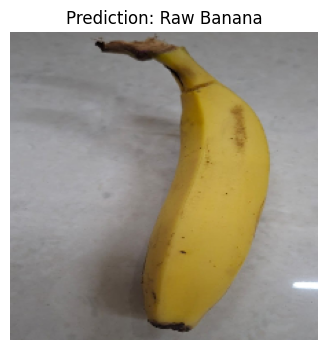

Predicted class: Raw Banana


In [83]:
banana_class_names = ['Fresh Banana', 'Raw Banana', 'Stale Banana']
predict_and_show_image('/kaggle/input/dataset2/Dataset2/Test/Fresh Banana/WhatsApp Image 2025-04-22 at 12.04.31 AM.jpeg', banana_freshness_model, banana_class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


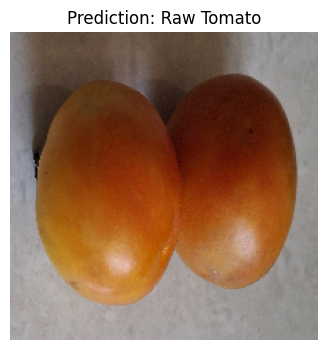

Predicted class: Raw Tomato


In [84]:
tomato_class_names = ['Fresh Tomato', 'Raw Tomato', 'Stale Tomato']
predict_and_show_image('/kaggle/input/dataset2/Dataset2/Test/Fresh Tomato/20250212_161215.jpg', tomato_freshness_model, tomato_class_names)
